## Oppgave 1a)
$$\frac{d^2y}{dx^2} = -4\sin(2x), \quad y(0) = 0, \quad y'(0) = 2$$
$$\frac{dy}{dx} = \int -4\sin(2x)\,dx = 2\cos(2x) + C_1$$
$$y = \int 2\cos(2x) + C_1\,dx = \sin(2x) + C_1x + C_2$$
$$y(0) = 0 \implies \sin(0) + C_1\cdot 0 + C_2 = 0 \implies C_2 = 0$$
$$y'(0) = 2 \implies 2\cos(0) + C_1 = 2 \implies C_1 = 0$$
$$y = \sin(2x)$$

## oppgave 1b)

$$\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix}, \quad \vec{y}'(x) = \begin{pmatrix} y'(x) \\ y''(x) \end{pmatrix} = \begin{pmatrix} y'(x) \\ -4\sin(2x) \end{pmatrix}$$
$$\vec{y}(0) = \begin{pmatrix} y(0) \\ y'(0) \end{pmatrix} = \begin{pmatrix} 0 \\ 2 \end{pmatrix}$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_bvp
from numba.typed import List, Dict
from numba import njit, types
import numpy.typing as npt
dict_type = types.DictType(types.unicode_type, types.float64)

def plot_solution(
        ax: plt.Axes, 
        X: npt.NDArray[np.float64], 
        Y: npt.NDArray[np.float64], 
        label: str = "",
        xlabel: str="x", 
        ylabel: str ="y", 
        **plot_kwargs,
        ) -> None:
    """Plot a single solution on the given axes."""

    ax.plot(X, Y, label=label, **plot_kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if label:
        ax.legend()

## Oppgave 1c)

0.005867474594997992 1071 0


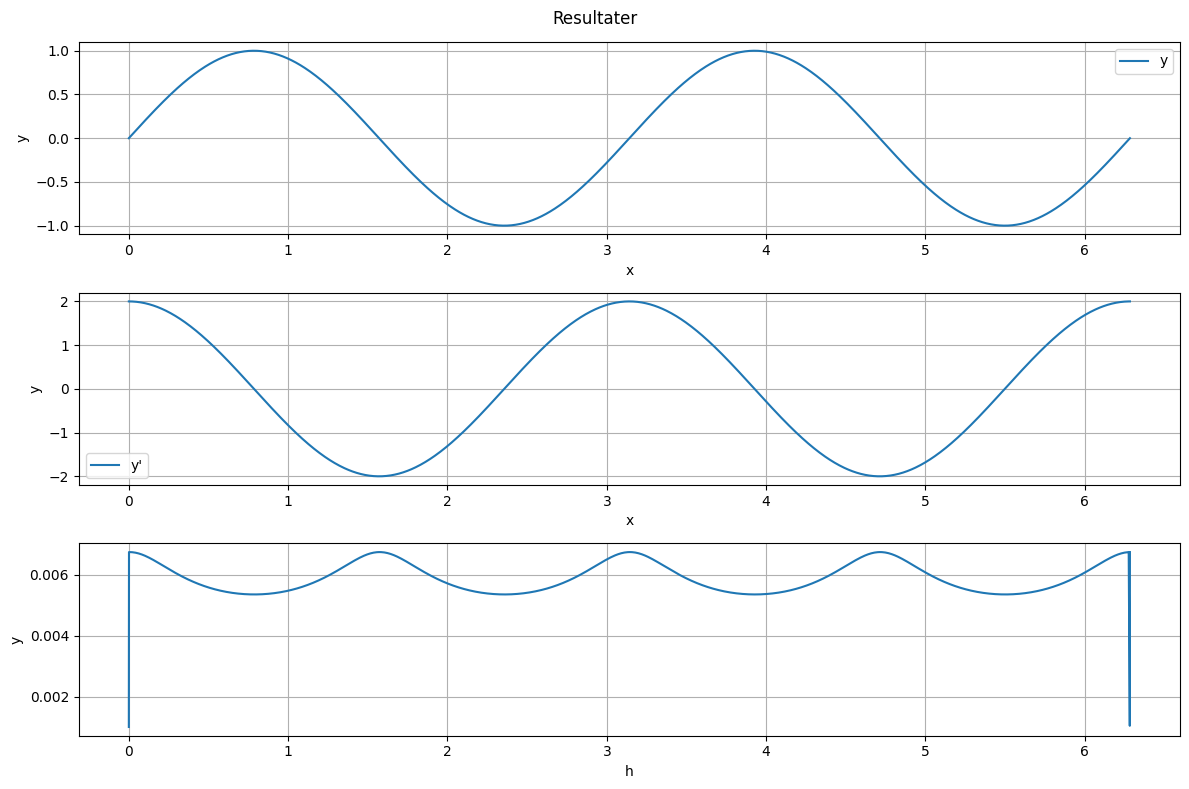

In [ ]:
params = Dict.empty(
    key_type=types.unicode_type,
    value_type=types.float64
)

params["x_init"] = 0.0
params["x_end"]= 2*np.pi
params["y_0"] = 0.0
params["y'_0"] = 2.0
params["h_0"] = 1e-3
params["tol"] = 1e-7
params["alpha"] = 0.8


@njit
def diff_system_1(x:float,y:float) -> npt.NDArray[np.float64]:
    """calculates y' and y'' from x, y, y' and the first given differential system."""
    return  np.array([y[1], -4*np.sin(2*x)]) 

@njit
def IVP_solver_1(params: Dict[str,float]) -> tuple[List, List, List, List, int, int]:
    """ solves the first given differential system using rk3 and adjusting step length with rk4"""
    accepted = 0
    rejected = 0
    x_list = List()
    h_list = List()
    y_list = List.empty_list(types.float64[:])
    z_list = List.empty_list(types.float64[:])
    x_list.append(params["x_init"])
    y_init = np.empty(2, dtype=np.float64)
    y_init[0] = params["y_0"]
    y_init[1] = params["y'_0"]
    y_list.append(y_init)
    h_list.append(params["h_0"])
    k_1 = diff_system_1(x_list[0],y_list[0])

    while x_list[accepted]<params["x_end"]:
        h_list[accepted] = min(h_list[accepted], params["x_end"]-x_list[accepted])
        k_2 = diff_system_1(x_list[accepted]+1/2*h_list[accepted], y_list[accepted] + 1/2*h_list[accepted]*k_1)
        k_3 = diff_system_1(x_list[accepted] + 3/4*h_list[accepted], y_list[accepted] + 3/4*h_list[accepted]*k_2)
        y_new= y_list[accepted] + 1/9*h_list[accepted]*(2*k_1+3*k_2+4*k_3)
        x_new = x_list[accepted] + h_list[accepted]
        k_4 = diff_system_1(x_new,y_new)
        z_new = y_list[accepted] + 1/24*h_list[accepted]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        est = np.sqrt(np.sum((y_new - z_new)**2))
        h_new = (params["alpha"] * h_list[accepted] * (params["tol"]/est)**(1/3))
        if est < params["tol"]:
            accepted+=1
            k_1=k_4
            y_list.append(y_new)
            x_list.append(x_new)
            z_list.append(z_new)
            h_list.append(h_new)
        else: 
            h_list[accepted] = h_new
            rejected +=1
    return x_list, y_list, z_list, h_list, accepted, rejected

x_list, y_list, z_list, h_list, accepted, rejected = IVP_solver_1(params)
y_array = np.stack(y_list)
fig, axes = plt.subplots(3, 1, figsize=[12,8])
plot_solution(ax=axes[0], X=np.array(x_list), Y = y_array[:,0], ylabel = "y")
plot_solution(ax=axes[1], X=np.array(x_list), Y = y_array[:,1], ylabel = "y'")
plot_solution(ax=axes[2], X=np.array(x_list), Y = np.array(h_list), ylabel = "h")
fig.suptitle("Resultater")
plt.tight_layout()
print(np.average(h_list),accepted, rejected)
 

## Oppgave 1d)

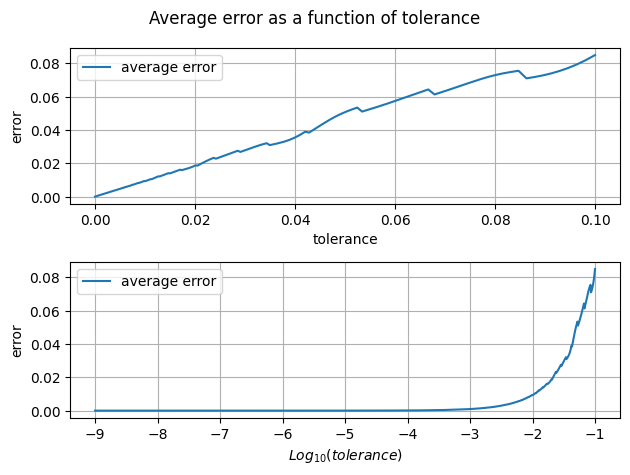

: 

In [ ]:
params["x_init"] = 0.0
params["x_end"]= 2*np.pi
params["y_0"] = 0.0
params["y'_0"] = 2.0
params["h_0"] = 1e-3
params["tol"] = 1e-3
params["alpha"] = 0.8

def solution(x: float) -> float:
    """returns the analytic solution y(x) = sin(2x)."""
    return np.sin(2*x)

exponent_array = np.linspace(1,9,1000)
error_avg_list = List()

for exp in exponent_array:
    params["tol"]=10**(-exp)
    x_list, y_list, _,_,_,_ = IVP_solver_1(params)
    y_array = np.stack(y_list)
    error_avg = np.linalg.norm(solution(np.array(x_list))-y_array[:,0])
    error_avg_list.append(error_avg)
error_avg_array = np.array(error_avg_list)


fig, ax = plt.subplots(2,1)
plot_solution(ax=ax[0], X=10**(-exponent_array), Y = error_avg_array, label = "average error", xlabel="tolerance", ylabel="error")
plot_solution(ax=ax[1], X=-exponent_array, Y = error_avg_array, label = "average error", xlabel="$Log_{10}(tolerance)$", ylabel="error")
fig.suptitle("Average error as a function of tolerance")
fig.tight_layout()

In [ ]:


alpha_array = np.linspace(0.8,1,1000)
accepted_list = List()
rejected_list = List()
for alpha in alpha_array:
    params["alpha"] = alpha
    _,_,_,_,accepted,rejected = IVP_solver_1(params)
    accepted_list.append(accepted)
    rejected_list.append(rejected)
accepted_array= np.array(accepted_list)
rejected_array = np.array(rejected_list)
step_array = accepted_array + rejected_array

fig, ax = plt.subplots(3,1)
plot_solution(ax=ax[0], X=alpha_array, Y = step_array, xlabel="alpha", ylabel="Total steps")
plot_solution(ax=ax[1], X=alpha_array, Y = accepted_array, xlabel="alpha", ylabel="Accepted steps")
plot_solution(ax=ax[2], X=alpha_array, Y = rejected_array, xlabel="alpha", ylabel="Rejected steps")
fig.suptitle("Steps as a function of alpha")
fig.tight_layout()


## Oppgave 1e)

In [ ]:
def sekant_root_g(
        z_0:float,
        z_1:float, 
        params: Dict[str,float]) -> tuple[float, int]:
    """finds a root of g with the secant method."""
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n]-z[n-1])>params["tol"]:
        z.append((z[n-1]*g(z[n])-z[n]*g(z[n-1]))/(g(z[n])-g(z[n-1])))
        n+=1
    return z[n],n

def g(s: float) -> float:
    """defines the scalar function used in the secant test."""
    return s + np.sin(s) + np.cos(s)

print(sekant_root_g(-20.0,20.0,params))

(-0.45662470456763077, 7)


## Oppgave 1f)

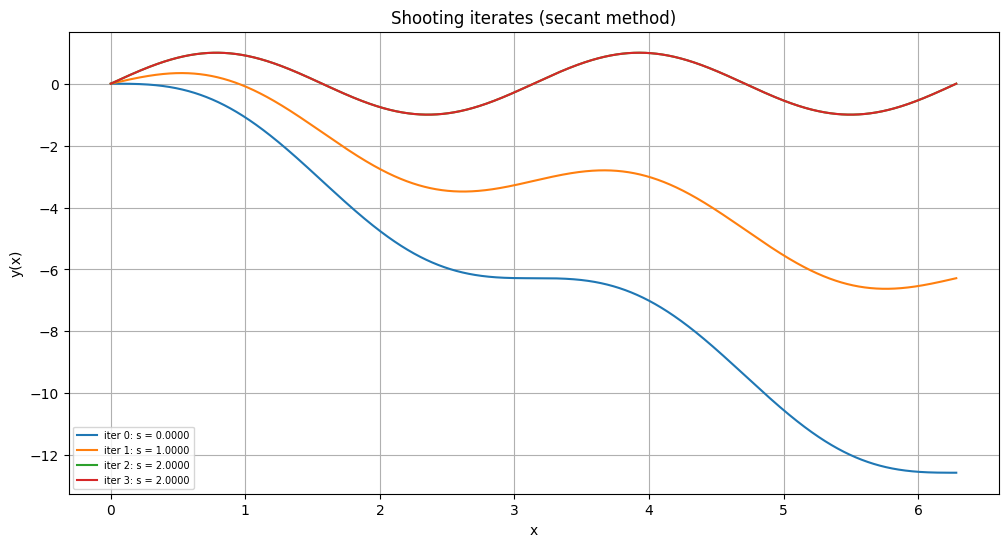

In [ ]:

def shoot_1(s: float, params: Dict[str,float]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """solves the first ivp for a guessed initial slope s."""
    params["y'_0"] = s
    x_list, y_list,_,_,_,_ = IVP_solver_1(params=params)
    y_array = np.stack(y_list)
    x_array = np.array(x_list)
    return x_array, y_array

def F_1( s: float, params: Dict[str,float]) -> float:
    """Shooting residual: y(xend) - yb."""
    _, Y = shoot_1(s, params)
    return Y[-1, 0]

def sekant_root_1(z_0:float, z_1:float, params: Dict[str,float]) -> tuple[float, int]:
    """finds the shooting slope for the first system with the secant method."""
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n-1]-z[n])>params["tol"]:
        z.append((z[n-1]*F_1(z[n],params)-z[n]*F_1(z[n-1],params))/(F_1(z[n],params)-F_1(z[n-1],params)))
        n+=1
    return z[n],n

def shooting_method_1(params: Dict[str,float], s_init: npt.NDArray[np.float64],shooting_tol:float) -> tuple[List, List, List]:
    """runs the shooting method for the first boundary value problem."""
    x_arrays = List()
    y_arrays = List()
    s_list = List()
    s_list.append(s_init[0])
    s_list.append(s_init[1])
    for s in s_init:
        x_array, y_array = shoot_1(s, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
    n=1
    while abs(s_list[n]-s_list[n-1]) >= shooting_tol:
        s_new,_ = sekant_root_1(s_list[n-1],s_list[n],params)
        s_list.append(s_new)
        x_array, y_array = shoot_1(s_new, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
        n+=1
    return s_list, x_arrays, y_arrays
s_list, x_arrays, y_arrays = shooting_method_1(params,np.array([0.0,1.0]),10**-10)

fig, ax = plt.subplots( figsize=(12,6))
for i in range(len(x_arrays)):
    plot_solution(ax=ax, X=x_arrays[i], Y = y_arrays[i][0:,0], label=f"iter {i}: s = {s_list[i]:.4f}")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("Shooting iterates (secant method)")
ax.grid(True)
ax.legend(fontsize=7)

## Oppgave 1g)

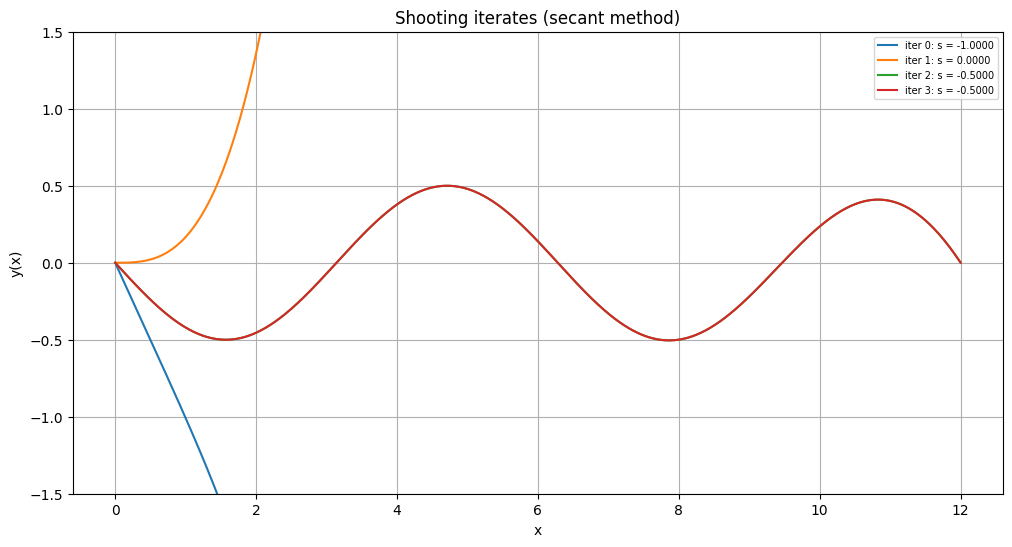

In [ ]:
params["x_init"] = 0.0
params["x_end"]= 12.0
params["y_0"] = 0.0
params["y'_0"] = 0.0
params["h_0"] = 1e-3
params["tol"] = 1e-7
params["alpha"] = 0.8
@njit
def diff_system_2(x:float,y:float) -> npt.NDArray[np.float64]:
    """calculates y' and y'' from x, y, y' and the second given differential system."""
    return np.array([y[1], y[0] + np.sin(x)])

@njit
def IVP_solver_2(params: Dict[str,float]) -> tuple[List, List, List, List, int, int]:
    """ solves the second given differential system using rk3 and adjusting step length with rk4"""
    accepted = 0
    rejected = 0
    x_list = List()
    h_list = List()
    y_list = List.empty_list(types.float64[:])
    z_list = List.empty_list(types.float64[:])
    x_list.append(params["x_init"])
    y_init = np.empty(2, dtype=np.float64)
    y_init[0] = params["y_0"]
    y_init[1] = params["y'_0"]
    y_list.append(y_init)
    h_list.append(params["h_0"])
    k_1 = diff_system_2(x_list[0],y_list[0])

    while x_list[accepted]<params["x_end"]:
        h_list[accepted] = min(h_list[accepted], params["x_end"]-x_list[accepted])
        k_2 = diff_system_2(x_list[accepted]+1/2*h_list[accepted], y_list[accepted] + 1/2*h_list[accepted]*k_1)
        k_3 = diff_system_2(x_list[accepted] + 3/4*h_list[accepted], y_list[accepted] + 3/4*h_list[accepted]*k_2)
        y_new= y_list[accepted] + 1/9*h_list[accepted]*(2*k_1+3*k_2+4*k_3)
        x_new = x_list[accepted] + h_list[accepted]
        k_4 = diff_system_2(x_new,y_new)
        z_new = y_list[accepted] + 1/24*h_list[accepted]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        est = np.sqrt(np.sum((y_new - z_new)**2))
        h_new = (params["alpha"] * h_list[accepted] * (params["tol"]/est)**(1/3))
        if est < params["tol"]:
            accepted+=1
            k_1=k_4
            y_list.append(y_new)
            x_list.append(x_new)
            z_list.append(z_new)
            h_list.append(h_new)
        else: 
            h_list[accepted] = h_new
            rejected +=1
    return x_list, y_list, z_list, h_list, accepted, rejected


def shoot_2(s: float, params: Dict[str,float]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """solves the second ivp for a guessed initial slope s."""
    params["y'_0"] = s
    x_list, y_list,_,_,_,_ = IVP_solver_2(params)
    y_array = np.stack(y_list)
    x_array = np.array(x_list)
    return x_array, y_array


def F_2( s: float, params) -> float:
    """Shooting residual: y(xend) - yb."""
    _, Y = shoot_2(s, params)
    return Y[-1, 0]


def sekant_root_2(z_0:float, z_1:float, params: Dict[str,float]) -> tuple[float, int]:
    """finds the shooting slope for the second system with the secant method."""
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n-1]-z[n])>params["tol"]:
        z.append((z[n-1]*F_2(z[n],params)-z[n]*F_2(z[n-1],params))/(F_2(z[n],params)-F_2(z[n-1],params)))
        n+=1
    return z[n],n

def shooting_method_2(params, s_init: npt.NDArray[np.float64],shooting_tol) -> tuple[List, List, List]:
    """runs the shooting method for the second boundary value problem."""
    x_arrays = List()
    y_arrays = List()
    s_list = List()
    s_list.append(s_init[0])
    s_list.append(s_init[1])
    for s in s_init:
        x_array, y_array = shoot_2(s, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
    n=1
    while abs(s_list[n]-s_list[n-1]) >= shooting_tol:
        s_new,_ = sekant_root_2(s_list[n-1],s_list[n],params)
        s_list.append(s_new)
        x_array, y_array = shoot_2(s_new, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
        n+=1
    return s_list, x_arrays, y_arrays
s_list, x_arrays, y_arrays =shooting_method_2(params,np.array([-1.0,0.0]),10**-5)
fig, ax = plt.subplots( figsize=(12,6))
for i in range(len(x_arrays)):
    plot_solution(ax=ax, X=x_arrays[i], Y = y_arrays[i][0:,0], label=f"iter {i}: s = {s_list[i]:.4f}")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_ylim(-1.5, 1.5)
ax.set_title("Shooting iterates (secant method)")
ax.grid(True)
ax.legend(fontsize=7)

## Oppgave 1h)


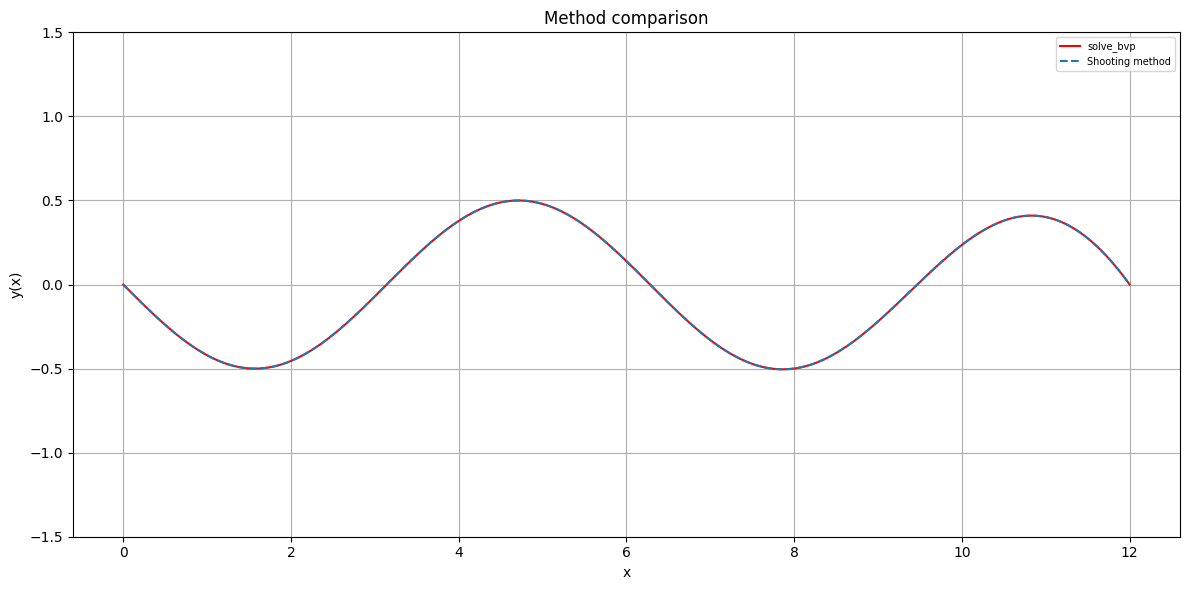

In [ ]:
def diff_system_2_plain(x:float, y:float) -> npt.NDArray[np.float64]:
    """defines the second system in the format solve_bvp expects."""
    return np.array([y[1], y[0] + np.sin(x)])

s_list, x_arrays, y_arrays =shooting_method_2(params,np.array([-1.0,0.0]),10**-5)
def bc_2(y_a:float,y_b:float) -> npt.NDArray[np.float64]:
    """defines the boundary conditions for solve_bvp"""
    return np.array([y_a[0],y_b[0]])
x_0 = np.linspace(params["x_init"],params["x_end"],100)
solution = solve_bvp(diff_system_2_plain, bc_2, x_0, np.zeros((2, x_0.size)))
Y_sol = solution.sol(x_arrays[-1])

fig, ax = plt.subplots(figsize=(12, 6))
plot_solution(ax, x_arrays[-1], Y_sol[0], label="solve_bvp", color="red")
plot_solution(ax, x_arrays[-1],  y_arrays[-1][:,0], label="Shooting method", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("Method comparison")
ax.set_ylim(-1.5, 1.5)
ax.grid(True)
ax.legend(fontsize=7)
plt.tight_layout()
